<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/credit_card_fraud_detection/blob/main/credit_card_fraud_detection_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection — Model Training & Evaluation

This notebook trains, tunes, evaluates, and explains the XGBoost fraud detection model using the processed datasets generated in **Notebook 1**.

## Objectives

- Load the processed datasets
- Optimize XGBoost hyperparameters with Optuna
- Train the final production model
- Optimize the decision threshold using a business cost matrix
- Explain model predictions with SHAP
- Save the trained model and explainability artifacts

### Outputs

- Trained XGBoost model
- SHAP feature-importance plot
- Model evaluation metrics

## Environment Setup

Prepare the Colab environment, load the project modules, and configure the pipeline.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!git clone https://github.com/narendrapatel6321-dotcom/credit_card_fraud_detection.git
%cd credit_card_fraud_detection

Cloning into 'credit_card_fraud_detection'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 100 (delta 37), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 167.09 KiB | 2.78 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/credit_card_fraud_detection


In [3]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 25.1 MB/s eta 0:00:00


In [4]:
# Standard library
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project modules
from src.config import PipelineConfig
from src.data_pipeline import ImbalanceAnalyzer
from src.model_trainer import FraudModelTrainer
from src.evaluator import (
    CostMatrixEvaluator,
    ExplainabilityEngine,
)

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [5]:
PROJECT_DIR = Path("/content/drive/MyDrive/CreditCardFraud")

PROCESSED_DIR = PROJECT_DIR / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
config = PipelineConfig(
    MODEL_SAVE_PATH=ARTIFACTS_DIR / "model.json",
    TRANSFORMER_STATS_PATH=ARTIFACTS_DIR / "transformer_stats.json",
    SHAP_PLOT_PATH=ARTIFACTS_DIR / "shap_summary.png",
)

## Load Processed Datasets

Load the processed train, validation, and test datasets generated in Notebook 1.

In [7]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_val = pd.read_csv(PROCESSED_DIR / "X_val.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")

y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()
y_val = pd.read_csv(PROCESSED_DIR / "y_val.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

In [8]:
summary = pd.DataFrame(
    {
        "Rows": [
            len(X_train),
            len(X_val),
            len(X_test),
        ],
        "Fraud Rate (%)": [
            y_train.mean() * 100,
            y_val.mean() * 100,
            y_test.mean() * 100,
        ],
    },
    index=["Train", "Validation", "Test"],
)

display(summary)

,Rows,Fraud Rate (%)
Train,198608,0.166660
Validation,42559,0.166827
Test,42559,0.166827


In [9]:
display(X_train.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Time_sin,Time_cos,Time_hour,Amount_log1p,Amount_is_round,Amount_scaled
0,1.132089,0.194386,0.362150,0.588889,-0.271681,-0.398920,-0.099188,0.087250,-0.188893,-0.152785,1.970844,0.874799,-0.290774,0.027749,0.673683,0.342699,0.118127,-0.269962,-0.345081,-0.107427,-0.191899,-0.603157,0.165303,0.174239,0.068777,0.094035,-0.014924,0.020603,-0.972658,0.232243,18,2.707383,0,-0.111815
1,-0.353027,-0.955101,1.715869,-1.862038,-1.993162,-0.171555,-0.058185,0.015741,-2.497221,0.997858,1.205402,-0.523280,0.400343,-0.379629,-0.071727,-0.060908,0.196679,0.980619,-0.134217,0.149578,0.186909,0.544119,0.334098,0.508283,-0.072215,-0.179250,0.007009,0.037677,-0.539383,-0.842060,14,5.303305,1,2.465482
2,-0.646948,0.994754,2.041892,-0.318653,0.402454,0.073120,0.533261,-0.314370,1.680931,-0.920658,-0.325931,-2.783280,1.886013,1.115550,0.652530,-0.103787,0.026911,0.716029,0.806653,0.048154,-0.321418,-0.553597,-0.395771,-0.756263,0.332744,-0.713647,-0.353967,-0.151089,0.974419,0.224738,5,1.137833,0,-0.276283
3,-4.049534,-0.342911,-2.343460,-0.124219,2.275074,1.049156,1.202889,-0.393204,1.771429,1.124097,1.498819,0.069429,-0.633774,-2.853114,0.271748,-0.557232,1.693482,-0.150431,-0.091932,-1.399246,-0.642015,0.452424,0.251046,-1.079154,-0.377491,-0.347974,-0.903836,2.017586,-0.029375,-0.999568,12,4.551453,0,0.993592
4,1.940494,-0.501533,0.047406,0.595139,-0.976805,-0.395403,-0.808078,0.030049,1.332178,0.017032,-1.038787,0.285470,0.164859,-0.283429,0.738337,0.671373,-0.709739,0.109722,-0.333920,-0.158223,0.023395,0.186586,0.283139,-0.102873,-0.526160,0.173262,0.004812,-0.032236,-0.681466,0.731850,21,3.291755,0,0.053067


## Hyperparameter Optimization

Rather than manually selecting XGBoost hyperparameters, Optuna performs Bayesian optimization using the Tree-structured Parzen Estimator (TPE).

The objective is to maximize the **validation PR-AUC**, which is more informative than ROC-AUC for highly imbalanced classification problems.

In [10]:
imbalance = ImbalanceAnalyzer(config)

imbalance_stats = imbalance.analyze(y_train.to_frame())

scale_pos_weight = imbalance_stats["scale_pos_weight"]

display(pd.DataFrame([imbalance_stats]))

,total_rows,negative_count,positive_count,negative_frequency,positive_frequency,imbalance_ratio,scale_pos_weight
0,198608,198277,331,0.998333,0.001667,599.024169,599.024169


In [11]:
trainer = FraudModelTrainer(config)

In [12]:
best_params = trainer.optimize(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    scale_pos_weight=scale_pos_weight,
)

In [13]:
optimization_results = pd.DataFrame(
    {
        "Hyperparameter": [
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "gamma",
            "reg_alpha",
            "reg_lambda",
            "min_child_weight",
        ],
        "Search Range": [
            f"[{config.XGB_MAX_DEPTH_MIN}, {config.XGB_MAX_DEPTH_MAX}]",
            f"[{config.XGB_LR_MIN}, {config.XGB_LR_MAX}] (log)",
            f"[{config.XGB_SUBSAMPLE_MIN}, {config.XGB_SUBSAMPLE_MAX}]",
            f"[{config.XGB_COLSAMPLE_MIN}, {config.XGB_COLSAMPLE_MAX}]",
            f"[{config.XGB_GAMMA_MIN}, {config.XGB_GAMMA_MAX}]",
            f"[{config.XGB_REG_ALPHA_MIN:.0e}, {config.XGB_REG_ALPHA_MAX}] (log)",
            f"[{config.XGB_REG_LAMBDA_MIN:.0e}, {config.XGB_REG_LAMBDA_MAX}] (log)",
            f"[{config.XGB_MIN_CHILD_WEIGHT_MIN}, {config.XGB_MIN_CHILD_WEIGHT_MAX}]",
        ],
        "Selected": [
            best_params["max_depth"],
            f"{best_params['learning_rate']:.5f}",
            f"{best_params['subsample']:.4f}",
            f"{best_params['colsample_bytree']:.4f}",
            f"{best_params['gamma']:.4f}",
            f"{best_params['reg_alpha']:.6f}",
            f"{best_params['reg_lambda']:.6f}",
            best_params["min_child_weight"],
        ],
    }
)

display(optimization_results)

,Hyperparameter,Search Range,Selected
0,max_depth,"[3, 10]",7
1,learning_rate,"[0.005, 0.3] (log)",0.09079
2,subsample,"[0.5, 1.0]",0.5103
3,colsample_bytree,"[0.5, 1.0]",0.9850
4,gamma,"[0.0, 5.0]",4.1622
5,reg_alpha,"[1e-08, 1.0] (log)",0.000000
6,reg_lambda,"[1e-08, 1.0] (log)",0.000000
7,min_child_weight,"[1, 20]",4


In [14]:
optimization_summary = pd.DataFrame(
    {
        "Metric": [
            "Optimization Algorithm",
            "Sampler",
            "Objective",
            "Trials",
            "Early Stopping",
            "Best Validation PR-AUC",
            "Best Boosting Rounds",
        ],
        "Value": [
            "Optuna",
            "TPE Sampler",
            "Validation PR-AUC",
            config.OPTUNA_N_TRIALS,
            config.EARLY_STOPPING_ROUNDS,
            f"{trainer.best_val_aucpr_:.4f}",
            trainer.best_n_estimators_,
        ],
    }
)

display(optimization_summary)

,Metric,Value
0,Optimization Algorithm,Optuna
1,Sampler,TPE Sampler
2,Objective,Validation PR-AUC
3,Trials,50
4,Early Stopping,50
5,Best Validation PR-AUC,0.8797
6,Best Boosting Rounds,258


## Final Model Training

Using the optimized hyperparameters, the final XGBoost model is trained with early stopping on the validation set. The resulting booster is then saved for future inference and analysis.

In [15]:
booster = trainer.train_final(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    scale_pos_weight=scale_pos_weight,
)

In [16]:
trainer.save_model(booster)

In [17]:
model_summary = pd.DataFrame(
    {
        "Property": [
            "Model",
            "Training Algorithm",
            "Optimization",
            "Evaluation Metric",
            "Model Path",
        ],
        "Value": [
            "XGBoost Booster",
            "Gradient Boosted Decision Trees",
            "Optuna (TPE)",
            "Validation PR-AUC",
            str(config.MODEL_SAVE_PATH),
        ],
    }
)

display(model_summary)

,Property,Value
0,Model,XGBoost Booster
1,Training Algorithm,Gradient Boosted Decision Trees
2,Optimization,Optuna (TPE)
3,Evaluation Metric,Validation PR-AUC
4,Model Path,/content/drive/MyDrive/CreditCardFraud/artifac...


## Business Cost-Based Threshold Optimization

The XGBoost model outputs fraud probabilities.

Rather than using the default classification threshold of **0.50**, the optimal decision threshold is selected by minimizing the expected business cost using an asymmetric cost matrix:

- False Negative cost = **$100**
- False Positive cost = **$5**

This produces a threshold better aligned with real-world fraud detection objectives.

In [18]:
y_test_proba = trainer.predict_proba(
    booster,
    X_test,
)

In [19]:
evaluator = CostMatrixEvaluator(config)

In [20]:
threshold_result = evaluator.find_optimal_threshold(
    y_true=y_test,
    y_proba=y_test_proba,
)

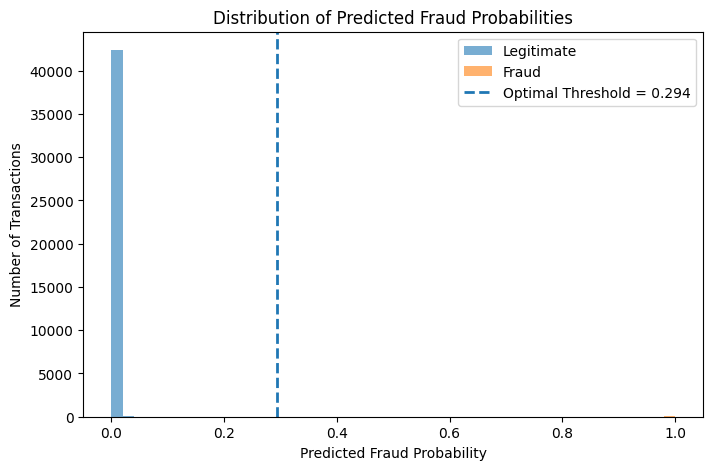

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    y_test_proba[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Legitimate",
)

plt.hist(
    y_test_proba[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Fraud",
)

plt.axvline(
    threshold_result.optimal_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Optimal Threshold = {threshold_result.optimal_threshold:.3f}",
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Predicted Fraud Probabilities")

plt.legend()

plt.show()

In [22]:
threshold_summary = pd.DataFrame(
    {
        "Metric": [
            "Optimal Threshold",
            "Minimum Business Cost",
            "Precision",
            "Recall",
            "F1 Score",
        ],
        "Value": [
            threshold_result.optimal_threshold,
            threshold_result.minimum_total_cost,
            threshold_result.precision,
            threshold_result.recall,
            threshold_result.f1_score,
        ],
    }
)

display(threshold_summary)

,Metric,Value
0,Optimal Threshold,0.293707
1,Minimum Business Cost,1260.000000
2,Precision,0.830986
3,Recall,0.830986
4,F1 Score,0.830986


In [23]:
confusion_summary = pd.DataFrame(
    {
        "Count": [
            threshold_result.true_positive_count,
            threshold_result.false_positive_count,
            threshold_result.true_negative_count,
            threshold_result.false_negative_count,
        ]
    },
    index=[
        "True Positives",
        "False Positives",
        "True Negatives",
        "False Negatives",
    ],
)

display(confusion_summary)

,Count
True Positives,59
False Positives,12
True Negatives,42476
False Negatives,12


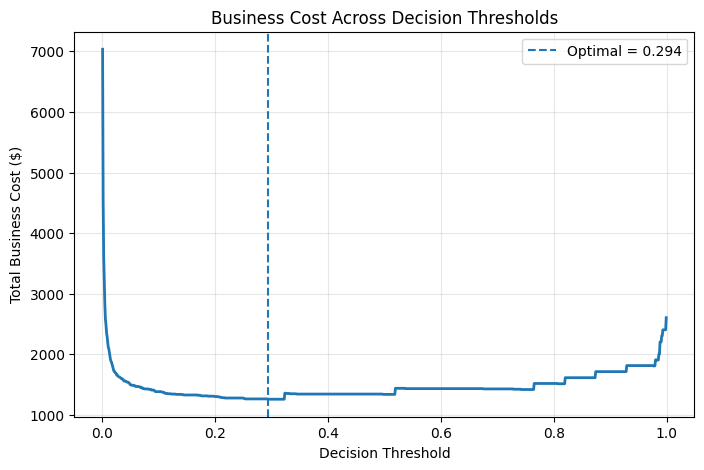

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_result.threshold_grid,
    threshold_result.cost_curve,
    linewidth=2,
)

plt.axvline(
    threshold_result.optimal_threshold,
    linestyle="--",
    label=f"Optimal = {threshold_result.optimal_threshold:.3f}",
)

plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost ($)")
plt.title("Business Cost Across Decision Thresholds")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Model Explainability

Although XGBoost is a powerful ensemble model, its predictions are not inherently interpretable.

To better understand the model's behavior, SHAP (SHapley Additive exPlanations) is used to quantify the contribution of each feature to the model's predictions.

The mean absolute SHAP value provides a measure of each feature's overall importance across the test dataset.

In [25]:
explainer = ExplainabilityEngine(config)

In [26]:
explanation = explainer.explain(
    booster=booster,
    X_test=X_test,
)

In [27]:
top_features = (
    explanation.mean_abs_shap
    .head(10)
    .rename("Mean |SHAP|")
    .reset_index()
)

top_features.columns = [
    "Feature",
    "Mean |SHAP|",
]

display(top_features)

,Feature,Mean |SHAP|
0,V4,3.066020
1,V14,2.764894
2,V12,1.999542
3,V11,1.274417
4,V3,1.148352
5,V26,1.076494
6,V1,0.976928
7,V10,0.920997
8,V8,0.906926
9,V24,0.772351


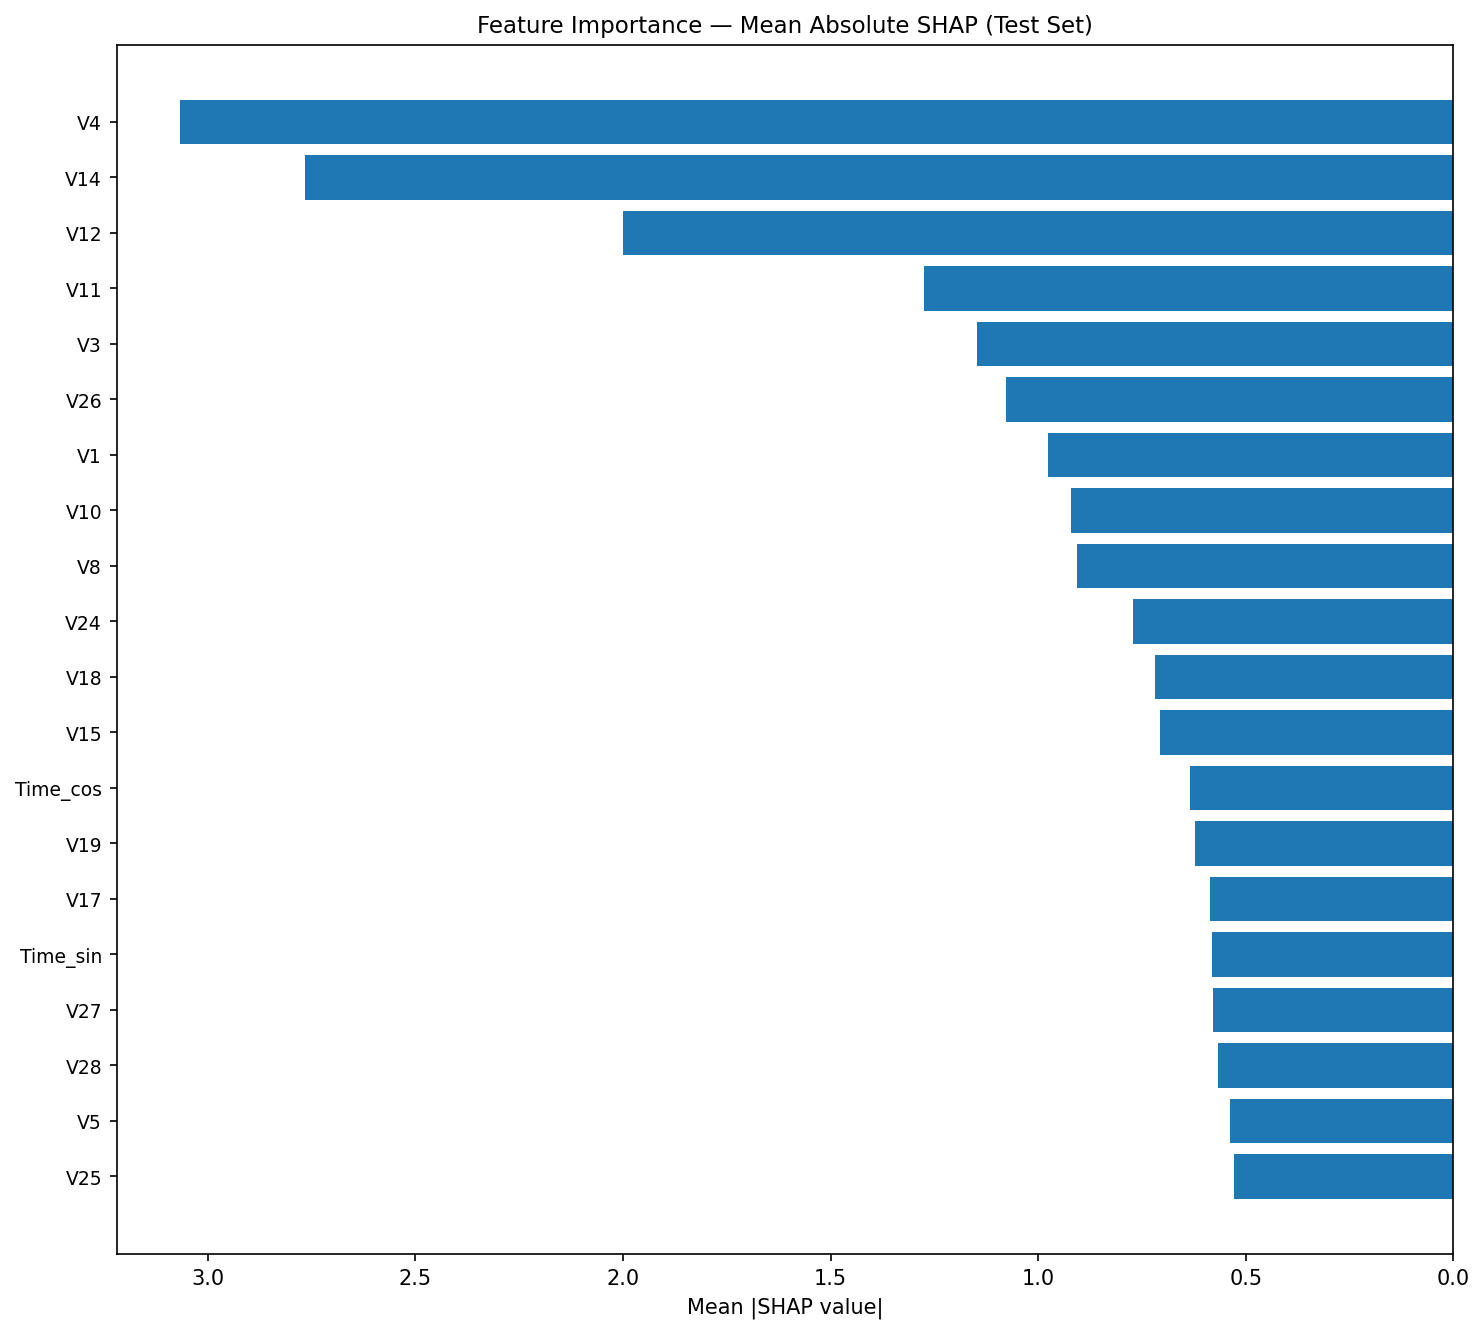

In [28]:
from IPython.display import Image, display

display(Image(filename=config.SHAP_PLOT_PATH))

### Interpretation

The SHAP feature importance plot summarizes the average contribution of each feature across the test dataset.

Features with larger mean absolute SHAP values have a greater influence on the model's fraud predictions.

These explanations improve transparency and provide confidence that the model is learning meaningful patterns rather than relying on arbitrary correlations.

## Pipeline Summary

The complete fraud detection pipeline has now been executed successfully.

### Completed Stages

- Loaded the processed datasets generated in Notebook 1
- Optimized XGBoost hyperparameters using Optuna
- Trained the final production model
- Optimized the classification threshold using a business cost matrix
- Explained model behavior using SHAP
- Saved the trained model and explainability artifacts

The resulting model is now ready for further experimentation or deployment.

In [29]:
artifact_summary = pd.DataFrame(
    {
        "Artifact": [
            "Trained Model",
            "Transformer Statistics",
            "SHAP Summary Plot",
        ],
        "Location": [
            str(config.MODEL_SAVE_PATH),
            str(config.TRANSFORMER_STATS_PATH),
            str(config.SHAP_PLOT_PATH),
        ],
    }
)

display(artifact_summary)

,Artifact,Location
0,Trained Model,/content/drive/MyDrive/CreditCardFraud/artifac...
1,Transformer Statistics,/content/drive/MyDrive/CreditCardFraud/artifac...
2,SHAP Summary Plot,/content/drive/MyDrive/CreditCardFraud/artifac...
